In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hosseinbadrnezhad/human-faces-dataset-male-female-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.05G/1.05G [01:02<00:00, 17.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions/1):
['women', 'men']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Output path for the split dataset
output_folder = "dataset_split"

# Split the dataset: 80% Train, 20% Val
# If you want 3 parts (Train/Val/Test), change ratio to (.8, .1, .1)
splitfolders.ratio(path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Split completed! New data is located at: {output_folder}")

Copying files: 2000 files [00:04, 460.20 files/s]

Split completed! New data is located at: dataset_split


In [ ]:
import os

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only print leaf directories
            print(f"{root}: {len(files)} images")

print("Verifying image counts after split:")
count_files(output_folder)

Verifying image counts after split:
dataset_split/val/women: 255 images
dataset_split/val/men: 146 images
dataset_split/train/women: 1018 images
dataset_split/train/men: 581 images


In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print(f'Found GPU at: {device_name}')

Found GPU at: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

img_size = (224, 224)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary')

val_generator = val_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary')

# Build VGG16 Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator)

Found 1599 images belonging to 2 classes.
Found 401 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8612 - loss: 0.3166 - val_accuracy: 0.9327 - val_loss: 0.1509
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9343 - loss: 0.1642 - val_accuracy: 0.9426 - val_loss: 0.1314
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9368 - loss: 0.1358 - val_accuracy: 0.9526 - val_loss: 0.1140
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9675 - loss: 0.1045 - val_accuracy: 0.9476 - val_loss: 0.1376
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9637 - loss: 0.0984 - val_accuracy: 0.9576 - val_loss: 0.1019
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9769 - loss: 0.0742 - val_accuracy: 0.9526 - val_loss: 0.1092
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9775 - loss: 0.0625 - val_accuracy: 0.9576 - v

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 983ms/step - accuracy: 0.9601 - loss: 0.0940
Validation Loss: 0.09398128092288971
Validation Accuracy: 0.9600997567176819


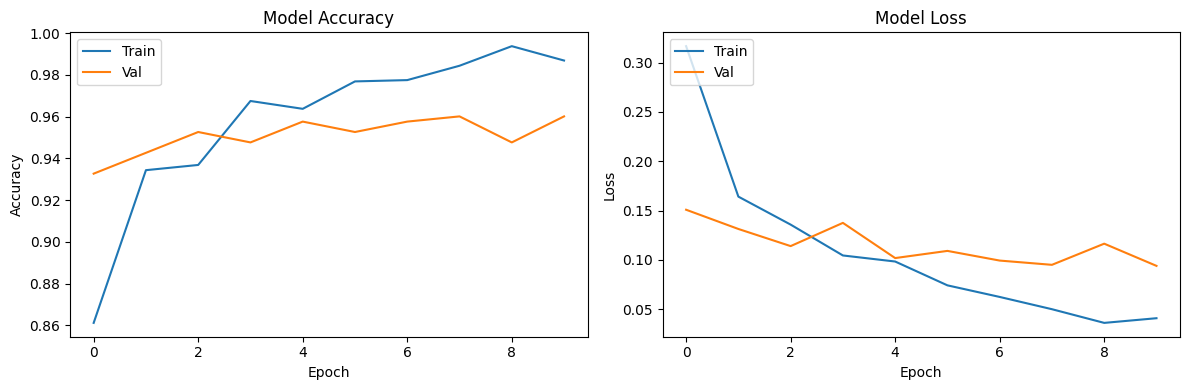

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()